Провести разведочный анализ данных о продажах кофейного автомата: 
  *  оценить качество и полноту данных,
  *  изучить динамику транзакций и выручки,
  *  определить структуру спроса,
  *  выявить временные закономерности и аномалии,
  *  сформулировать гипотезы для дальнейшего анализа.


## 1. Загрузка и первичная проверка данных

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [46]:
df=pd.read_csv('../data/index_1.csv',parse_dates=['date','datetime'])
display(df.head())
print('----------------------')
df.info()
print('----------------------')
print(f'Начало сбора данных: {df['date'].min()}, конец сбора данных: {df['date'].max()}')
print('----------------------')

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


----------------------
<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   datetime64[us]
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 287.9 KB
----------------------
Начало сбора данных: 2024-03-01 00:00:00, конец сбора данных: 2025-03-23 00:00:00
----------------------


In [47]:
missing_summary=pd.DataFrame({
    'missing_count':df.isna().sum(),
    'missing_procent':df.isna().mean().mul(100).round(2)
})

display(missing_summary)

duplicate_count=df.duplicated().sum()

print(f'Количество дубликатов: {duplicate_count}')

,missing_count,missing_procent
date,0,0.00
datetime,0,0.00
cash_type,0,0.00
card,89,2.45
money,0,0.00
coffee_name,0,0.00


Количество дубликатов: 0


In [48]:
df_null=df[df['card'].isna()]
print(f'Всего строк с null: {len(df_null)} из них с оплатой cash: {len(df_null[df_null['cash_type']=='cash'])}, c оплатой картой: {len(df_null[df_null['cash_type']=='card'])}')

Всего строк с null: 89 из них с оплатой cash: 89, c оплатой картой: 0


In [49]:
display(df['cash_type'].value_counts())
display(df['coffee_name'].value_counts())

cash_type
card    3547
cash      89
Name: count, dtype: int64

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

In [50]:
calendar = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = calendar.difference(df['date'].unique())

missing_dates

DatetimeIndex(['2024-05-01', '2024-05-04', '2024-05-05', '2024-11-27',
               '2025-01-01', '2025-01-19', '2025-01-23'],
              dtype='datetime64[us]', freq=None)

In [51]:
date_mismatches = (
    df['date'] != df['datetime'].dt.normalize()
).sum()

date_mismatches


np.int64(0)

In [52]:
print(f'Минимальная сумма операции: {df["money"].min()}')
print(f'Максимальная сумма операции: {df["money"].max()}')
print(f'Нулевых или отрицательных сумм: {(df["money"] <= 0).sum()}')

Минимальная сумма операции: 18.12
Максимальная сумма операции: 40.0
Нулевых или отрицательных сумм: 0


Общий итог по загруженным данным:
  * всего 3636 строк с 6 признаками
  * пропущенные значения в 89 строках в полях card, они связаны с отсутствием номера карты при оплате наличными
  * нет дубликатов
  * некорректных дат (когда время транзакции не совпадает date) не обнаружено
  * обнаружено 7 дней, по которым нет данных о транзакциях (по данным невозможно определить были ли это дни без продаж или это аномалии в сборе данных)
  * нулевых или отрицательных сумм не обнаружено
  * суммы операций находятся в диапазоне от 18.12 до 40.00

  >  Для построения непрерывного временного ряда отсутствующим датам присваивается нулевое 
  >  количество зарегистрированных транзакций. Это техническое допущение: по данным нельзя
  >  однозначно судить, что было в упомянутые дни.

(array([19783., 19844., 19905., 19967., 20028., 20089., 20148.]),
 [Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03')])

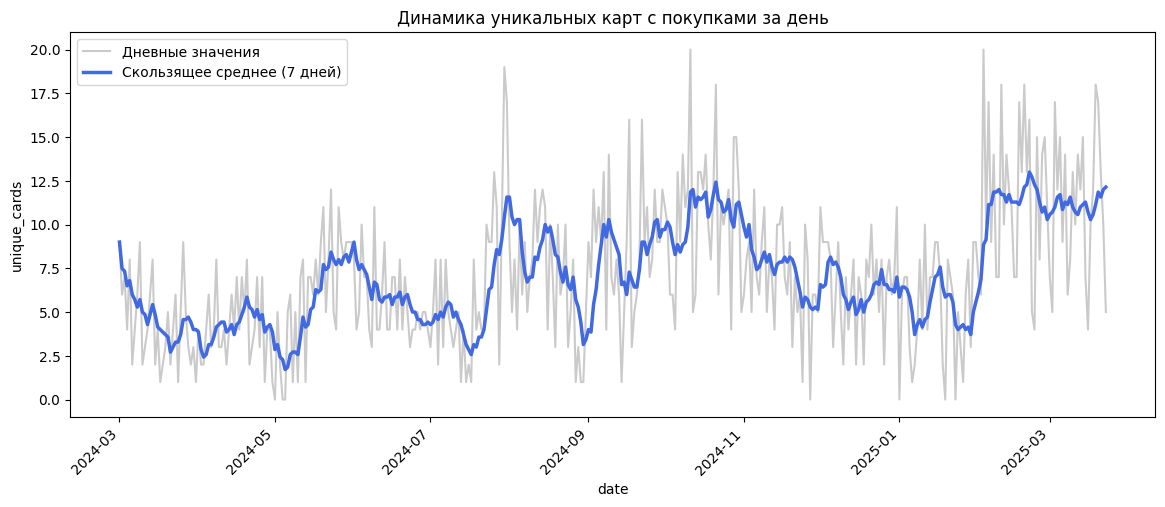

In [53]:
daily_unique_cards = (
    df.set_index('date')
      .resample('D')
      .agg(unique_cards=('card', 'nunique'))
)

daily_unique_cards['rolling_7d']=(
    daily_unique_cards['unique_cards'].rolling('7D',min_periods=1).mean()
)

plt.figure(figsize=(14,5))
sns.lineplot(data=daily_unique_cards, x='date',y='unique_cards',label='Дневные значения', color='gray', alpha=0.41)
sns.lineplot(data=daily_unique_cards, x='date',y='rolling_7d',label='Скользящее среднее (7 дней)', color='royalblue', linewidth=2.5)

plt.title("Динамика уникальных карт с покупками за день")
plt.xticks(rotation=45,ha='right')

(array([19783., 19844., 19905., 19967., 20028., 20089., 20148.]),
 [Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03')])

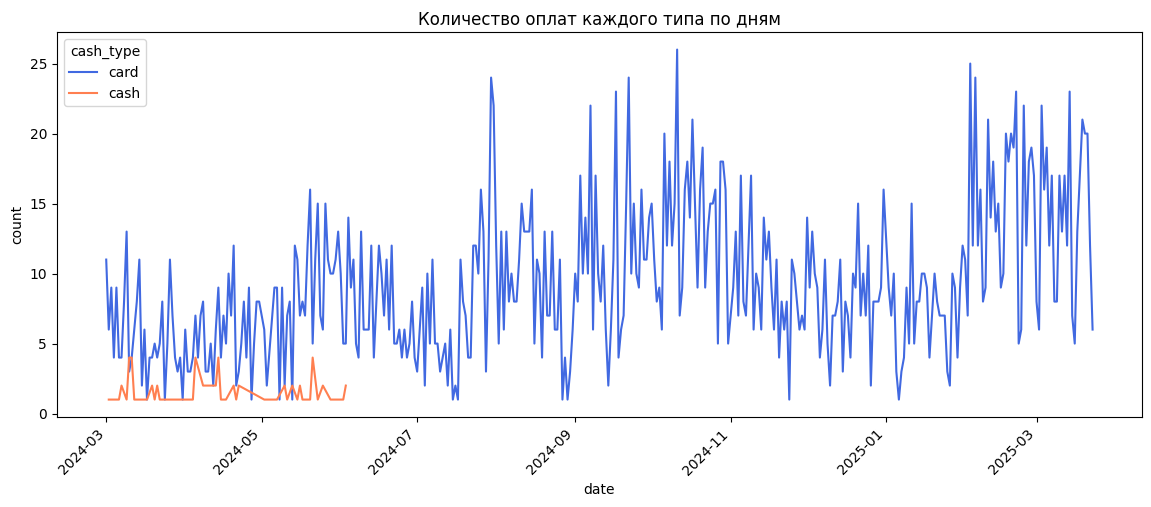

In [54]:
payments_daily=df.groupby(['date','cash_type']).size().reset_index(name='count')

plt.figure(figsize=(14,5))
sns.lineplot(data=payments_daily,x='date',y='count',hue='cash_type',palette=['royalblue','coral'])

plt.title('Количество оплат каждого типа по дням')
plt.xticks(rotation=45, ha='right')

(array([19783., 19797., 19814., 19828., 19844., 19858., 19875., 19889.,
        19905.]),
 [Text(19783.0, 0, '2024-03-01'),
  Text(19797.0, 0, '2024-03-15'),
  Text(19814.0, 0, '2024-04-01'),
  Text(19828.0, 0, '2024-04-15'),
  Text(19844.0, 0, '2024-05-01'),
  Text(19858.0, 0, '2024-05-15'),
  Text(19875.0, 0, '2024-06-01'),
  Text(19889.0, 0, '2024-06-15'),
  Text(19905.0, 0, '2024-07-01')])

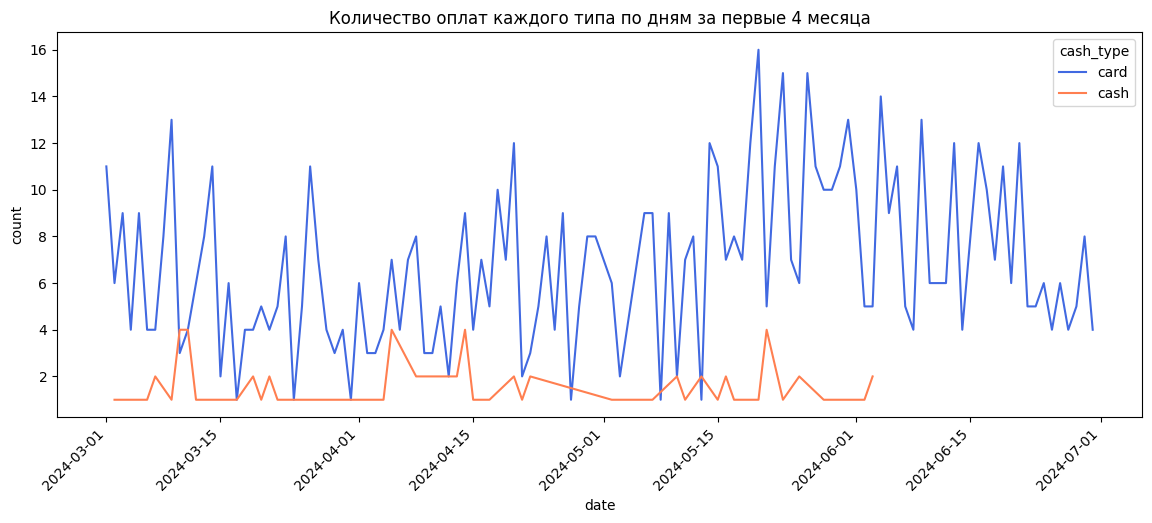

In [55]:
payments_daily_4m=payments_daily[payments_daily['date']<'2024-07-01']
plt.figure(figsize=(14,5))
sns.lineplot(data=payments_daily_4m,x='date',y='count',hue='cash_type',palette=['royalblue','coral'])

plt.title('Количество оплат каждого типа по дням за первые 4 месяца')
plt.xticks(rotation=45, ha='right')

In [56]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [57]:
start_date = df['date'].min()
cash_end_date = df[df['cash_type'] == 'cash']['date'].max()

period_dates = pd.date_range(start_date, cash_end_date)
all_dates = pd.date_range(start_date, df['date'].max())

cash_period_data = (df[df['cash_type'] == 'cash']
                    .pivot_table(index='date', columns='coffee_name', values='datetime', aggfunc='count', fill_value=0)
                    .reindex(period_dates, fill_value=0)
                    .cumsum())

card_period_data = (df[(df['cash_type'] == 'card') & (df['date'] <= cash_end_date)]
                    .pivot_table(index='date', columns='coffee_name', values='datetime', aggfunc='count', fill_value=0)
                    .reindex(period_dates, fill_value=0)
                    .cumsum())

card_all_time_data = (df[df['cash_type'] == 'card']
                      .pivot_table(index='date', columns='coffee_name', values='datetime', aggfunc='count', fill_value=0)
                      .reindex(all_dates, fill_value=0)
                      .cumsum())


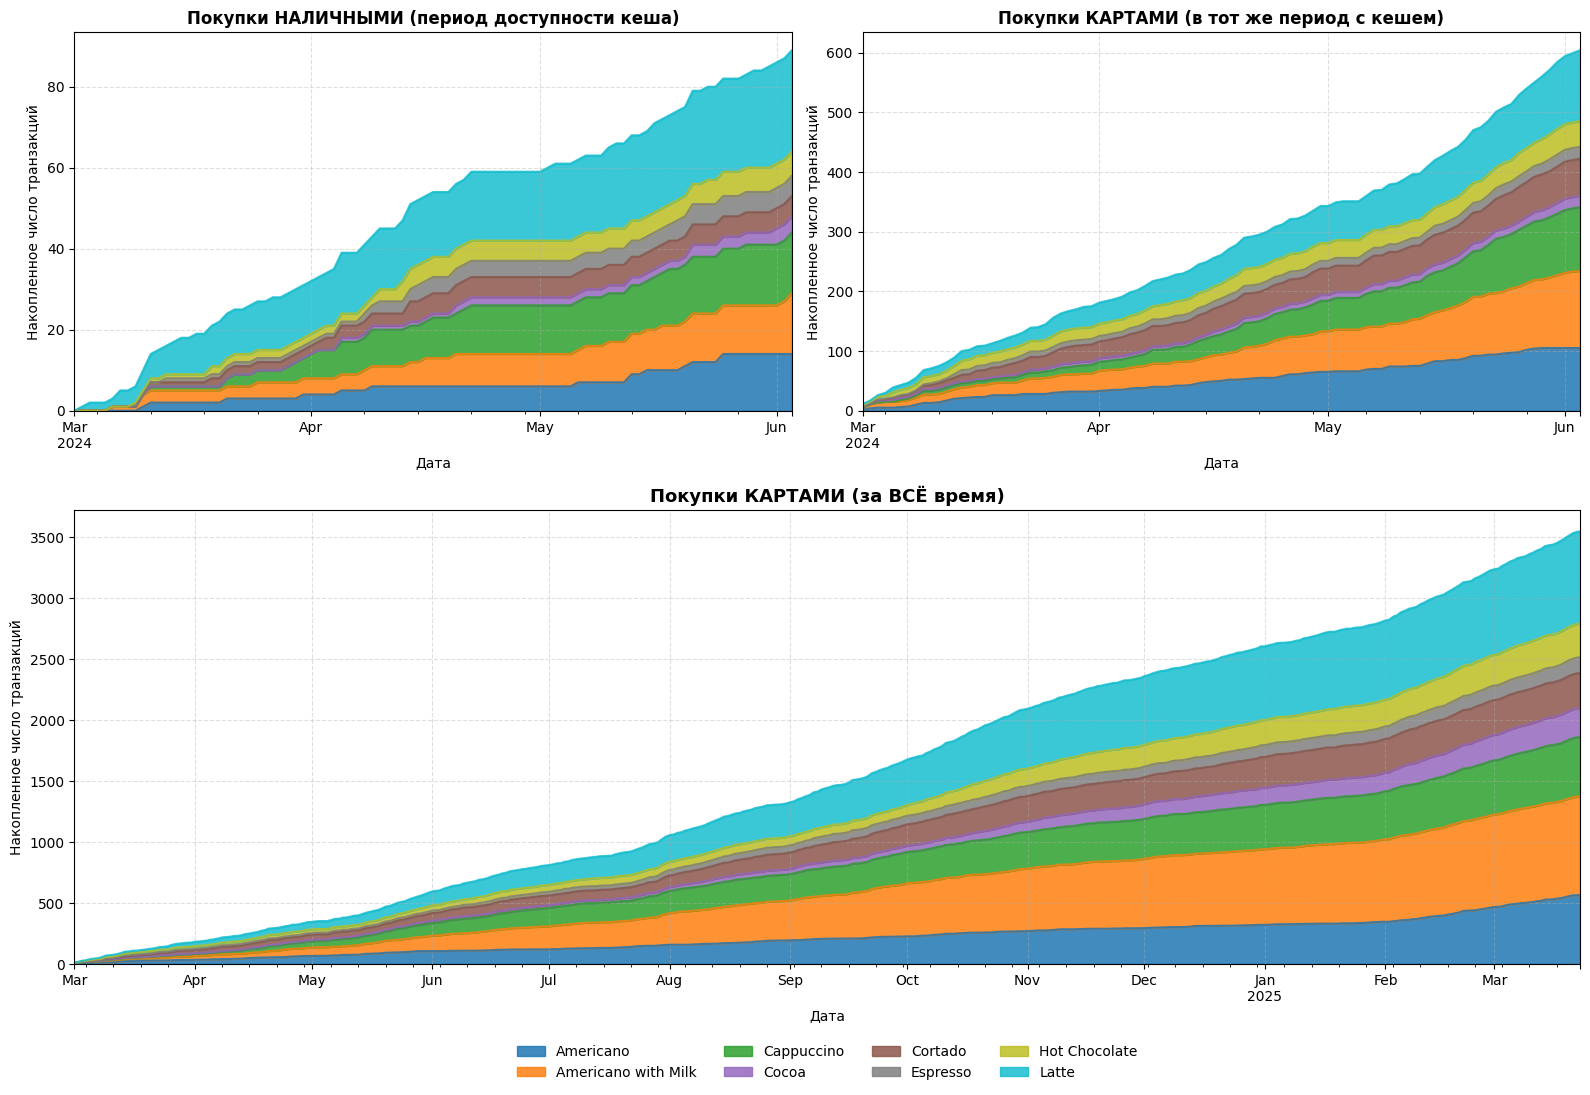

In [58]:
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# --- График 1 (Слева сверху: Наличные) ---
cash_period_data.plot.area(ax=ax1, alpha=0.85, colormap='tab10', legend=False)
ax1.set_title('Покупки НАЛИЧНЫМИ (период доступности кеша)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Накопленное число транзакций')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- График 2 (Справа сверху: Карты за тот же период) ---
card_period_data.plot.area(ax=ax2, alpha=0.85, colormap='tab10', legend=False)
ax2.set_title('Покупки КАРТАМИ (в тот же период с кешем)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Накопленное число транзакций')
ax2.grid(True, linestyle='--', alpha=0.4)

# --- График 3 (Внизу: Карты за ВСЁ время) ---
card_all_time_data.plot.area(ax=ax3, alpha=0.85, colormap='tab10')
ax3.set_title('Покупки КАРТАМИ (за ВСЁ время)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Дата')
ax3.set_ylabel('Накопленное число транзакций')
ax3.grid(True, linestyle='--', alpha=0.4)

ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


  > После 3 июня в датасете отсутствуют наличные операции. Это может отражать
  > изменение способа оплаты или сбора данных, но установить причину по имеющимся
  > полям невозможно.

## 2. Динамика транзакций и выручки

In [59]:
last_month_start = df['date'].max().to_period('M').start_time
complete_months_df = df[df['date'] < last_month_start]

Последний месяц наблюдений является неполным, поэтому он исключен из сравнения полных календарных месяцев.

In [60]:
monthly_sales = (
      complete_months_df
      .set_index('date')
      .resample('MS')
      .agg(
          transactions=('money', 'size'),
          revenue=('money', 'sum'),
          average_transaction=('money', 'mean')
      )
      .reset_index()
)

monthly_sales

,date,transactions,revenue,average_transaction
0,2024-03-01,206,7050.20,34.224272
1,2024-04-01,196,6720.56,34.288571
2,2024-05-01,267,9063.42,33.945393
3,2024-06-01,227,7758.76,34.179559
4,2024-07-01,237,6915.94,29.181181
5,2024-08-01,272,7613.84,27.992059
6,2024-09-01,344,9988.64,29.036744
7,2024-10-01,426,13891.16,32.608357
8,2024-11-01,259,8590.54,33.168108
9,2024-12-01,259,8237.74,31.805946


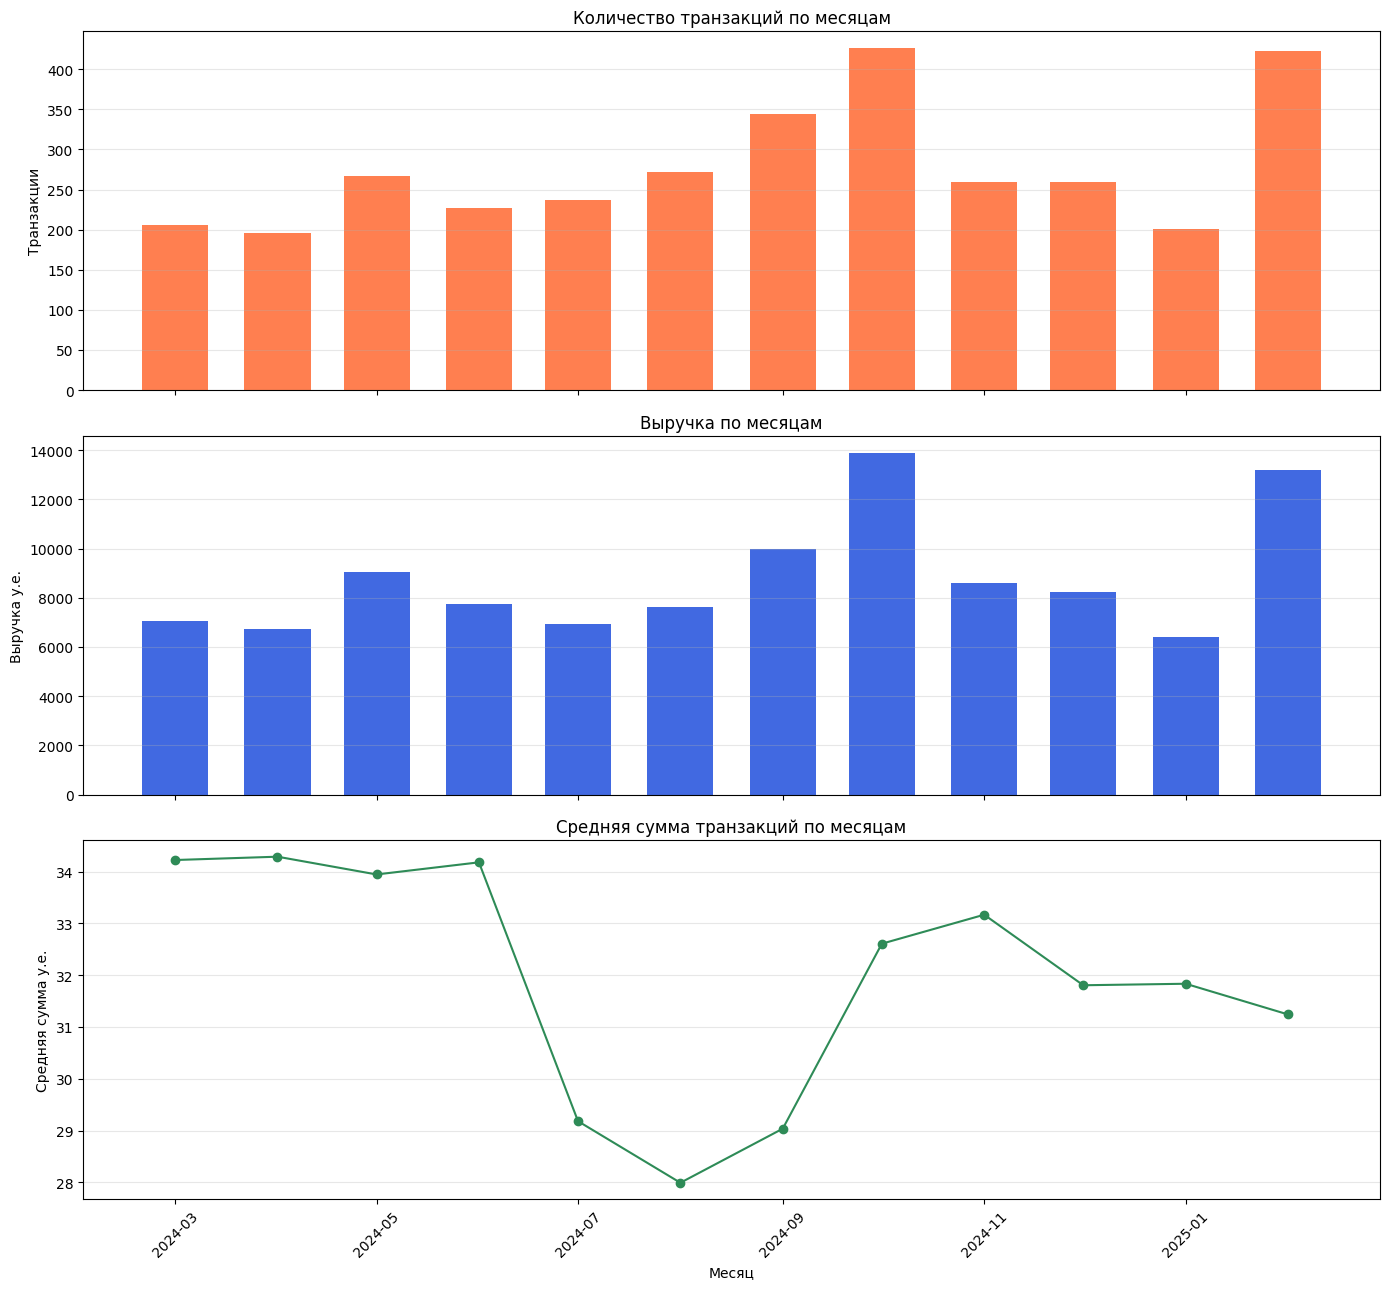

In [ ]:
fig,axes=plt.subplots(3,1,figsize=(14,13),sharex=True)

axes[0].bar(monthly_sales['date'],monthly_sales['transactions'],width=20,color='coral')
axes[0].set_title('Количество транзакций по месяцам')
axes[0].set_ylabel('Транзакции')

axes[1].bar(monthly_sales['date'],monthly_sales['revenue'],width=20,color='royalblue')
axes[1].set_title('Выручка по месяцам')
axes[1].set_ylabel('Выручка у.е.')

axes[2].plot(monthly_sales['date'],monthly_sales['average_transaction'],marker='o',color='seagreen')
axes[2].set_title('Средняя сумма транзакции по месяцам')
axes[2].set_ylabel('Средняя сумма у.е.')
axes[2].set_xlabel('Месяц')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

In [64]:
max_transactions_month=monthly_sales.loc[monthly_sales['transactions'].idxmax()]

min_transactions_month=monthly_sales.loc[monthly_sales['transactions'].idxmin()]


max_revenue_month=monthly_sales.loc[monthly_sales['revenue'].idxmax()]

min_revenue_month=monthly_sales.loc[monthly_sales['revenue'].idxmin()]


max_average_month = monthly_sales.loc[monthly_sales['average_transaction'].idxmax()]

min_average_month = monthly_sales.loc[monthly_sales['average_transaction'].idxmin()]


print(f'Максимальное число транзакций в {max_transactions_month['date'].month_name()}',
                                        f'{max_transactions_month['date'].year} :',
                                        f'{max_transactions_month['transactions']}')
print(f'Минимальное число транзакций в {min_transactions_month['date'].month_name()}',
                                        f'{min_transactions_month['date'].year} :',
                                        f'{min_transactions_month['transactions']}')
print('-----------------------------------')
print(f'Максимальная выручка в {max_revenue_month['date'].month_name()}',
                                        f'{max_revenue_month['date'].year} :',
                                        f'{max_revenue_month['revenue']} у.е.')
print(f'Минимальная выручка в {min_revenue_month['date'].month_name()}',
                                        f'{min_revenue_month['date'].year} :',
                                        f'{min_revenue_month['revenue']} у.е.')
print('-----------------------------------')
print(
      f'Максимальная средняя сумма транзакции: '
      f'{max_average_month["average_transaction"]:.2f} у. е. - '
      f'{max_average_month["date"]:%Y-%m}')

print(
      f'Минимальная средняя сумма транзакции: '
      f'{min_average_month["average_transaction"]:.2f} у. е. - '
      f'{min_average_month["date"]:%Y-%m}')


Максимальное число транзакций в October 2024 : 426
Минимальное число транзакций в April 2024 : 196
-----------------------------------
Максимальная выручка в October 2024 : 13891.16 у.е.
Минимальная выручка в January 2025 : 6398.86 у.е.
-----------------------------------
Максимальная средняя сумма транзакции: 34.29 у. е. - 2024-04
Минимальная средняя сумма транзакции: 27.99 у. е. - 2024-08


Общий итог по анализу транзакций и выручки:  
*  в анализе не было марта 2025 так как данные по нему неполные(доступны сведения о транзакциях, которые произошли ранее 24 марта 2025 года)
*  больше всего транзакций и выручки было в октябре 2024, 426 транзакций и 13 891.16 у.е. соответственно
*  меньше всего транзакций было в апреле 2024 : 196 транзакций
*  меньше всего выручки среди полных месяцев было в январе 2025 - 6398.86 у.е.
*  по графику видно, что график выручки повторяет поведение графика транзакций